In [1]:
!pip install diffusers accelerate torchvision torch

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Dataset loaded successfully. Total batches: 938
Model, scheduler, and optimizer initialized.

Starting training loop...
Epoch [1/5] | Batch [0/938] | Loss: 1.1426
Epoch [1/5] | Batch [200/938] | Loss: 0.0590
Epoch [1/5] | Batch [400/938] | Loss: 0.0504
Epoch [1/5] | Batch [600/938] | Loss: 0.0481
Epoch [1/5] | Batch [800/938] | Loss: 0.0380
=== Epoch 1 Complete | Average Loss: 0.0559 ===

Epoch [2/5] | Batch [0/938] | Loss: 0.0311
Epoch [2/5] | Batch [200/938] | Loss: 0.0227
Epoch [2/5] | Batch [400/938] | Loss: 0.0211
Epoch [2/5] | Batch [600/938] | Loss: 0.0328
Epoch [2/5] | Batch [800/938] | Loss: 0.0337
=== Epoch 2 Complete | Average Loss: 0.0311 ===

Epoch [3/5] | Batch [0/938] | Loss: 0.0225
Epoch [3/5] | Batch [200/938] | Loss: 0.0249
Epoch [3/5] | Batch [400/938] | Loss: 0.0259
Epoch [3/5] | Batch [600/938] | Loss: 0.0304
Epoch [3/5] | Batch [800/938] | Loss: 0.0318
=== Epoch 3 Complete | Average Loss: 0.0283 ===

Epoch [4/5] | Batch [0/938] | Loss: 0.0242
Ep

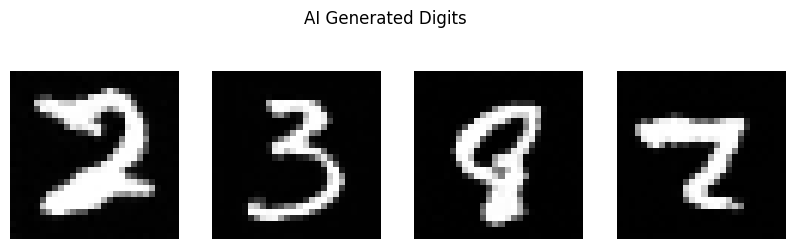

In [2]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import UNet2DModel, DDPMScheduler


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)
print(f"Dataset loaded successfully. Total batches: {len(train_loader)}")


model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 64),
    down_block_types=(
        "DownBlock2D", 
        "AttnDownBlock2D", 
        "AttnDownBlock2D"
    ),
    up_block_types=(
        "AttnUpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D"
    )
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
print("Model, scheduler, and optimizer initialized.")

epochs = 5  

print("\nStarting training loop...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # 1. Sample pure Gaussian noise
        noise = torch.randn_like(images)
        
        # 2. Sample random timesteps for the batch
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()
        
        
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)
        
        
        noise_pred = model(noisy_images, timesteps).sample
        
        
        loss = F.mse_loss(noise_pred, noise)
        
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        
        if batch_idx % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    epoch_loss = running_loss / len(train_loader)
    print(f"=== Epoch {epoch+1} Complete | Average Loss: {epoch_loss:.4f} ===\n")


torch.save(model.state_dict(), "mnist_diffusion_model.pth")
print("Training finished! Weights saved to 'mnist_diffusion_model.pth'.")

print("\nGenerating new sample digits from random noise...")
model.eval()

sample = torch.randn(4, 1, 28, 28).to(device)


for t in reversed(range(len(noise_scheduler.timesteps))):
    timestep = torch.tensor([t], device=device)
    
    with torch.no_grad():
        
        noise_pred = model(sample, timestep).sample
        
    
    sample = noise_scheduler.step(noise_pred, t, sample).prev_sample


sample = (sample / 2 + 0.5).clamp(0, 1).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(sample[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle("AI Generated Digits")
plt.show()

Using device: cuda
Dataset loaded successfully. Total batches: 938
Model, scheduler, and optimizer initialized.

Starting training loop...
Epoch [1/20] | Batch [0/938] | Loss: 0.9933
Epoch [1/20] | Batch [200/938] | Loss: 0.0499
Epoch [1/20] | Batch [400/938] | Loss: 0.0381
Epoch [1/20] | Batch [600/938] | Loss: 0.0355
Epoch [1/20] | Batch [800/938] | Loss: 0.0286
=== Epoch 1 Complete | Average Loss: 0.0555 ===

Epoch [2/20] | Batch [0/938] | Loss: 0.0339
Epoch [2/20] | Batch [200/938] | Loss: 0.0335
Epoch [2/20] | Batch [400/938] | Loss: 0.0345
Epoch [2/20] | Batch [600/938] | Loss: 0.0290
Epoch [2/20] | Batch [800/938] | Loss: 0.0283
=== Epoch 2 Complete | Average Loss: 0.0312 ===

Epoch [3/20] | Batch [0/938] | Loss: 0.0290
Epoch [3/20] | Batch [200/938] | Loss: 0.0299
Epoch [3/20] | Batch [400/938] | Loss: 0.0281
Epoch [3/20] | Batch [600/938] | Loss: 0.0322
Epoch [3/20] | Batch [800/938] | Loss: 0.0267
=== Epoch 3 Complete | Average Loss: 0.0282 ===

Epoch [4/20] | Batch [0/938] |

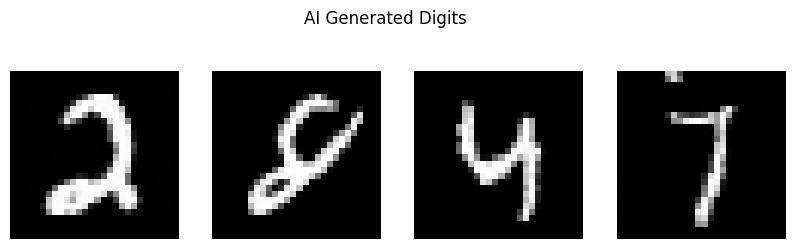

In [3]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import UNet2DModel, DDPMScheduler


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)
print(f"Dataset loaded successfully. Total batches: {len(train_loader)}")


model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 64),
    down_block_types=(
        "DownBlock2D", 
        "AttnDownBlock2D", 
        "AttnDownBlock2D"
    ),
    up_block_types=(
        "AttnUpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D"
    )
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
print("Model, scheduler, and optimizer initialized.")


epochs = 20 

print("\nStarting training loop...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # 1. Sample pure Gaussian noise
        noise = torch.randn_like(images)
        
        # 2. Sample random timesteps for the batch
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()
        
        # 3. Add noise to the clean images (Forward Diffusion)
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)
        
        # 4. Predict the added noise using the U-Net
        noise_pred = model(noisy_images, timesteps).sample
        
        # 5. Calculate loss (Mean Squared Error)
        loss = F.mse_loss(noise_pred, noise)
        
        # 6. Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Print update every 200 batches so you know it's working
        if batch_idx % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    epoch_loss = running_loss / len(train_loader)
    print(f"=== Epoch {epoch+1} Complete | Average Loss: {epoch_loss:.4f} ===\n")

# Save model weights
torch.save(model.state_dict(), "mnist_diffusion_model.pth")
print("Training finished! Weights saved to 'mnist_diffusion_model.pth'.")

# ==========================================
# STEP 5: INFERENCE (GENERATING NEW DIGITS)
# ==========================================
print("\nGenerating new sample digits from random noise...")
model.eval()

# Start with 4 channels of pure random noise
sample = torch.randn(4, 1, 28, 28).to(device)

# Backward Diffusion: Denoise step-by-step from timestep 999 down to 0
for t in reversed(range(len(noise_scheduler.timesteps))):
    timestep = torch.tensor([t], device=device)
    
    with torch.no_grad():
        # Predict the noise component
        noise_pred = model(sample, timestep).sample
        
    # Remove a slice of the predicted noise to get the slightly cleaner image
    sample = noise_scheduler.step(noise_pred, t, sample).prev_sample

# Denormalize images from [-1, 1] back to [0, 1] for plotting
sample = (sample / 2 + 0.5).clamp(0, 1).cpu().numpy()

# Plot the 4 generated images side-by-side
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(sample[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle("AI Generated Digits")
plt.show()

Using device: cuda

alpha_bar at various timesteps:
  t=   0:  alpha_bar = 0.999900
  t= 100:  alpha_bar = 0.895141
  t= 250:  alpha_bar = 0.521423
  t= 500:  alpha_bar = 0.077797
  t= 750:  alpha_bar = 0.003300
  t= 999:  alpha_bar = 0.000040


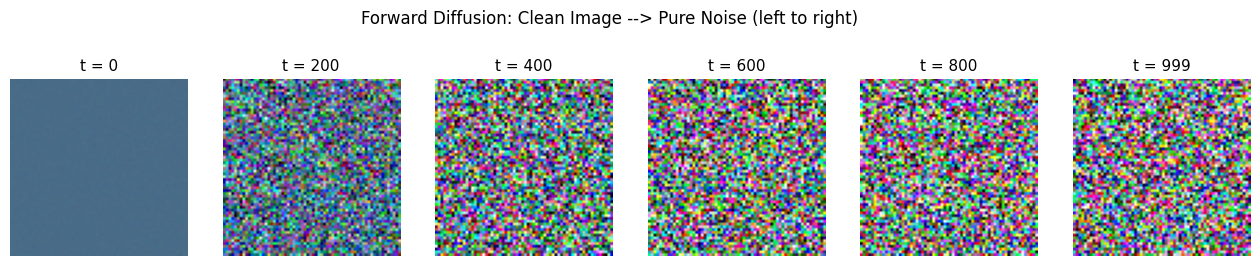

Saved: forward_diffusion.png

Number of parameters in U-Net: 101,121,795

Starting Training Loop...
Epoch 1/1  Step 0/10  Loss: 1.165667
Epoch 1/1  Step 2/10  Loss: 0.790986
Epoch 1/1  Step 4/10  Loss: 0.611253
Epoch 1/1  Step 6/10  Loss: 0.491039
Epoch 1/1  Step 8/10  Loss: 0.398167

Generating 4 images with 1000 denoising steps...
  Denoising step t= 800: internal pixel standard deviation = 3.071
  Denoising step t= 600: internal pixel standard deviation = 11.289
  Denoising step t= 400: internal pixel standard deviation = 30.599


In [ ]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torchvision import transforms
import torchvision.utils as vutils
from diffusers import UNet2DModel

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION & SIMULATED DATA SETUP
# ─────────────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

NUM_EPOCHS = 1
T = 1000

# Create a fake 'sample_image.jpg' so the script runs without file errors
if not os.path.exists("sample_image.jpg"):
    dummy_img = Image.new("RGB", (256, 256), color=(73, 109, 137))
    dummy_img.save("sample_image.jpg")

# Create dummy dataset for the training loop to consume
# 10 batches of fake RGB images scaled roughly to [-1, 1]
fake_images = torch.randn(640, 3, 64, 64)
fake_labels = torch.zeros(640)
dummy_dataset = TensorDataset(fake_images, fake_labels)
loader = DataLoader(dummy_dataset, batch_size=64, shuffle=True)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE THE NOISE SCHEDULE
# ─────────────────────────────────────────────────────────────────────────────
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

print("\nalpha_bar at various timesteps:")
for t_val in [0, 100, 250, 500, 750, 999]:
    print(f"  t={t_val:4d}:  alpha_bar = {alpha_bar[t_val].item():.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: THE FORWARD DIFFUSION FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def add_noise(x0, t):
    noise = torch.randn_like(x0)
    
    # Extract coefficients and match dimensions for broadcasting (B, 1, 1, 1)
    a = alpha_bar[t].sqrt().view(-1, 1, 1, 1)
    b = (1 - alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
    
    x_t = a * x0 + b * noise
    return x_t, noise

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: VISUALISE THE FORWARD PROCESS
# ─────────────────────────────────────────────────────────────────────────────
img = Image.open("sample_image.jpg").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
x0 = transform(img).unsqueeze(0)  # Shape: (1, 3, 64, 64)

timesteps_to_show = [0, 200, 400, 600, 800, 999]
fig, axes = plt.subplots(1, 6, figsize=(16, 3))

for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val])
    noisy_img, _ = add_noise(x0, t_tensor)

    # Convert back from [-1,1] to [0,1] for plotting
    display = (noisy_img[0].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    ax.imshow(display)
    ax.set_title(f"t = {t_val}", fontsize=11)
    ax.axis("off")

plt.suptitle("Forward Diffusion: Clean Image --> Pure Noise (left to right)", y=1.02)
plt.savefig("forward_diffusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: forward_diffusion.png\n")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: THE DENOISER (U-NET ARCHITECTURE)
# ─────────────────────────────────────────────────────────────────────────────
unet = UNet2DModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 512, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

optimizer = AdamW(unet.parameters(), lr=1e-4)
print(f"Number of parameters in U-Net: {sum(p.numel() for p in unet.parameters()):,}")

# Move schedule variables to the target hardware device for calculations
alphas = alphas.to(device)
alpha_bar = alpha_bar.to(device)
betas = betas.to(device)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: ONE TRAINING STEP
# ─────────────────────────────────────────────────────────────────────────────
def training_step(batch_of_clean_images):
    batch_size = batch_of_clean_images.shape[0]
    t = torch.randint(0, T, (batch_size,), device=device).long()
    
    x_t, actual_noise = add_noise(batch_of_clean_images.to(device), t)
    predicted_noise = unet(x_t, t).sample
    
    loss = F.mse_loss(predicted_noise, actual_noise)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: TRAINING LOOP RUNNER
# ─────────────────────────────────────────────────────────────────────────────
print("\nStarting Training Loop...")
for epoch in range(NUM_EPOCHS):
    for step, (images, _) in enumerate(loader):
        loss = training_step(images)
        if step % 2 == 0:  # Higher reporting cadence for short dummy loader
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}  Step {step}/{len(loader)}  Loss: {loss:.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: REVERSE DIFFUSION GENERATION (SAMPLING)
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def generate_images(unet, num_images=4, image_size=64):
    print(f"\nGenerating {num_images} images with {T} denoising steps...")
    unet.eval()
    
    # Begin with random Gaussian Noise
    x = torch.randn(num_images, 3, image_size, image_size).to(device)
    
    for t_val in reversed(range(T)):
        t_batch = torch.full((num_images,), t_val, dtype=torch.long, device=device)
        noise_pred = unet(x, t_batch).sample
        
        alpha_t = alphas[t_val]
        alpha_bar_t = alpha_bar[t_val]
        beta_t = betas[t_val]
        
        coefficient = beta_t / (1 - alpha_bar_t).sqrt()
        x_mean = (1 / alpha_t.sqrt()) * (x - coefficient * noise_pred)
        
        if t_val > 0:
            variance = beta_t * (1 - alpha_bar[t_val-1]) / (1 - alpha_bar_t)
            x = x_mean + variance.sqrt() * torch.randn_like(x)
        else:
            x = x_mean
            
        if t_val % 200 == 0:
            print(f"  Denoising step t={t_val:4d}: internal pixel standard deviation = {x.std().item():.3f}")
            
    images = (x.clamp(-1, 1) + 1) / 2
    print(f"Done! Generated images shape: {images.shape}")
    return images

# Execute generation and write result array matrix to disk
generated = generate_images(unet, num_images=4)
vutils.save_image(generated, "diffusion_samples.png", nrow=2)
print("Saved grid sample sheet: diffusion_samples.png")